# Lab 4: Improving and Comparing Machine Learning Models

Name : Nainsy Chawla

Student ID : 023-24-0261 

Section : H 

GitHub Profile : https://github.com/Nainsy-chawla/ML_Lab_Practise

Kaggle Profile :  https://www.kaggle.com/nainsychawla

Dataset : Telco Customer Churn dataset  

# 1. Decision Tree Baseline

In [19]:
# Task 1
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
df = pd.read_csv("clean_churn.csv")
y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop("Churn", axis=1)
X = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5608, 30)
X_test : (1402, 30)
y_train: (5608,)
y_test : (1402,)


Explanation :
The cleaned Telco Churn dataset was loaded and divided into input features X and target variable y. The data was split into 80% training and 20% testing using the same random_state as Lab 3 to ensure a fair comparison.

In [20]:
# task 2
dt_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred)
dt_precision = precision_score(y_test, y_pred)
dt_recall = recall_score(y_test, y_pred)
dt_f1 = f1_score(y_test, y_pred)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-score :", dt_f1)

Accuracy : 0.7931526390870185
Precision: 0.6310679611650486
Recall   : 0.5256064690026954
F1-score : 0.5735294117647058


Explanation : The Decision Tree was trained using the selected max_depth from Lab 3. Its accuracy, precision, recall, and F1-score provide the baseline performance that will be used to compare the Random Forest and tuned models.

# 2. Random Forest

In [21]:
# Task 3
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest trained successfully.")
print("Number of trees:", rf_model.n_estimators)

Random Forest trained successfully.
Number of trees: 200


Explanation :
The Random Forest was successfully trained using 200 Decision Trees. Instead of depending on one tree, it combines the predictions of many trees, which can produce a more stable and generalizable model.

#Task 4

Explanation :

Random Forest uses many Decision Trees instead of a single tree. Each tree learns from different samples and features, and their predictions are combined. This reduces the effect of overfitting and usually makes the model more stable than one unrestricted Decision Tree.ie : here we use 200 trees


# 3. Model Evaluation

Random Forest Performance
-------------------------
Accuracy : 0.7888730385164051
Precision: 0.631578947368421
Recall   : 0.48517520215633425
F1 Score : 0.5487804878048781

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1031
           1       0.63      0.49      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.71      1402
weighted avg       0.78      0.79      0.78      1402


Confusion Matrix:
[[926 105]
 [191 180]]


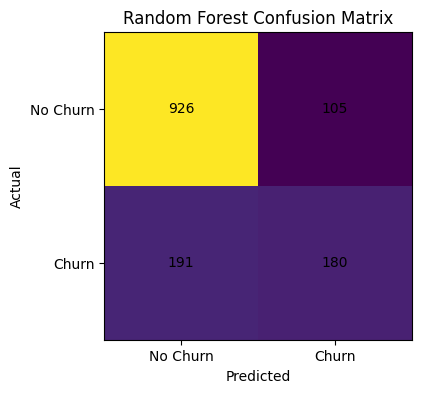

In [22]:
#Task 5
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

#Explanation :
The Random Forest has good overall accuracy (78.9%), but its recall for churn is low (48.5%). This means the model is better at predicting non-churning customers than churning customers. In this dataset, 191 actual churn customers were missed, so the model could be improved by focusing more on detecting Class 1.

# 4. Decision Tree vs Random Forest

In [23]:
# Task 6
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy],
    "Precision": [dt_precision, rf_precision],
    "Recall": [dt_recall, rf_recall],
    "F1 Score": [dt_f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.793153,0.631068,0.525606,0.573529
1,Random Forest,0.788873,0.631579,0.485175,0.548780


Explanation :
The Decision Tree performs slightly better overall than the Random Forest on the test set. It has higher accuracy (0.7932), recall (0.5256), and F1-score (0.5735), while Random Forest has almost the same but slightly higher precision (0.6316). Therefore, based on these four test-set metrics, the Decision Tree is currently better.

#Task 7

Expalnation :
The Decision Tree performs better overall because it has higher accuracy, recall, and F1-score, while Random Forest has only a slightly higher precision. The differences are generally marginal, with both models showing similar performance. Because the dataset has class imbalance, accuracy alone is not sufficient for comparison. Recall and F1-score are more important, especially recall because it measures how well the model identifies customers who actually churn. In this comparison, the Decision Tree has the higher recall and F1-score, giving it a small overall advantage.

# 5. Cross-Validation

In [24]:
# Task 8 
from sklearn.model_selection import cross_val_score
dt_cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Decision Tree CV F1 Scores:")
print(dt_cv_scores)

print("\nDecision Tree Mean F1:", dt_cv_scores.mean())
print("Decision Tree Std F1 :", dt_cv_scores.std())

print("\nRandom Forest CV F1 Scores:")
print(rf_cv_scores)

print("\nRandom Forest Mean F1:", rf_cv_scores.mean())
print("Random Forest Std F1 :", rf_cv_scores.std())

Decision Tree CV F1 Scores:
[0.56901408 0.5497076  0.5352518  0.56515373 0.57142857]

Decision Tree Mean F1: 0.5581111580728993
Decision Tree Std F1 : 0.013703979266036304

Random Forest CV F1 Scores:
[0.55521472 0.55130168 0.51796407 0.55625    0.57012195]

Random Forest Mean F1: 0.5501704863070209
Random Forest Std F1 : 0.0173147250238446


Explanation :
The Decision Tree achieved a mean F1-score of 0.5581, compared with 0.5502 for Random Forest. Decision Tree also had a lower standard deviation (0.0137 vs 0.0173), indicating more consistent performance across folds. The difference is small, so both models have similar performance, but Decision Tree has a slight advantage.

In [25]:
#Task 9
print("Decision Tree")
print("Test-set F1 :", dt_f1)
print("CV mean F1  :", dt_cv_scores.mean())
print("CV std      :", dt_cv_scores.std())

print("\nRandom Forest")
print("Test-set F1 :", rf_f1)
print("CV mean F1  :", rf_cv_scores.mean())
print("CV std      :", rf_cv_scores.std())

Decision Tree
Test-set F1 : 0.5735294117647058
CV mean F1  : 0.5581111580728993
CV std      : 0.013703979266036304

Random Forest
Test-set F1 : 0.5487804878048781
CV mean F1  : 0.5501704863070209
CV std      : 0.0173147250238446


Explanation :
The cross-validation results are generally consistent with the single train/test split. Decision Tree has a higher test-set F1-score (0.5735) and CV mean F1-score (0.5581) than Random Forest (0.5488 and 0.5502). The low standard deviations indicate that both models have reasonably consistent performance across different folds. Therefore, cross-validation does not change our conclusion that Decision Tree currently performs slightly better than Random Forest.

# 6. Hyperparameter Tuning

In [26]:
# task 10
from sklearn.model_selection import GridSearchCV

rf_for_tuning = RandomForestClassifier(
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid search completed.")

Grid search completed.


Explanation:
GridSearchCV tests different combinations of Random Forest hyperparameters. It uses 5-fold cross-validation to decide which combination gives the best F1-score instead of choosing parameters based only on one training/test split.

In [27]:
# Task 11
print("Best Hyperparameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Hyperparameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.5688283412278382


Explanation :
The best Random Forest configuration was max_depth=10, min_samples_split=5, and n_estimators=200. This combination achieved the highest cross-validation F1-score of 0.5688 among the tested combinations. The result suggests that limiting the tree depth and requiring at least 5 samples for splitting gave better validation performance than the other tested settings.

In [28]:
# Task 12
tuned_rf = grid_search.best_estimator_

y_pred_tuned = tuned_rf.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("Accuracy :", tuned_accuracy)
print("Precision:", tuned_precision)
print("Recall   :", tuned_recall)
print("F1 Score :", tuned_f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest Performance
--------------------------------
Accuracy : 0.8009985734664765
Precision: 0.6666666666666666
Recall   : 0.49595687331536387
F1 Score : 0.5687789799072643

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1031
           1       0.67      0.50      0.57       371

    accuracy                           0.80      1402
   macro avg       0.75      0.70      0.72      1402
weighted avg       0.79      0.80      0.79      1402



Explanation :
The tuned Random Forest achieved an accuracy of 0.8010, precision of 0.6667, recall of 0.4960, and F1-score of 0.5688 on the test set. Compared with the default Random Forest, the tuned model improved all four metrics. The F1-score also improved from 0.5488 to 0.5688, showing that hyperparameter tuning produced a better balance between precision and recall. However, the recall of 0.4960 shows that the model still misses some actual churn customers.

# 7. Final Model Comparison

In [29]:
# Task 13 
final_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        tuned_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        tuned_recall
    ],
    "F1 Score": [
        dt_f1,
        rf_f1,
        tuned_f1
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.793153,0.631068,0.525606,0.573529
1,Random Forest,0.788873,0.631579,0.485175,0.548780
2,Tuned Random Forest,0.800999,0.666667,0.495957,0.568779


# 8. Final Model Selection

Explanation :
The Tuned Random Forest achieved the highest accuracy (0.8010) and precision (0.6667), while the Decision Tree achieved the highest recall (0.5256) and F1-score (0.5735). Hyperparameter tuning improved the Random Forest compared with the default Random Forest across all four metrics. However, the Decision Tree still has a slightly higher F1-score and recall, which are important for the imbalanced churn dataset. Therefore, the final model should be selected by considering the overall evidence rather than accuracy alone.

#Task 14

Explanation :I selected the Decision Tree as the final model because it achieved the highest recall (0.5256) and F1-score (0.5735), which are important for the imbalanced churn dataset. Although the Tuned Random Forest achieved slightly higher accuracy (0.8010) and precision (0.6667), its F1-score (0.5688) and recall (0.4960) were slightly lower than the Decision Tree. Therefore, based on the overall evidence, the Decision Tree is the better choice for identifying churn customers.

# 9. Feature Importance

Top 5 Important Features:
tenure                         0.321495
InternetService_Fiber optic    0.260086
TotalCharges                   0.105608
MonthlyCharges                 0.077483
Contract_Two year              0.043749
dtype: float64


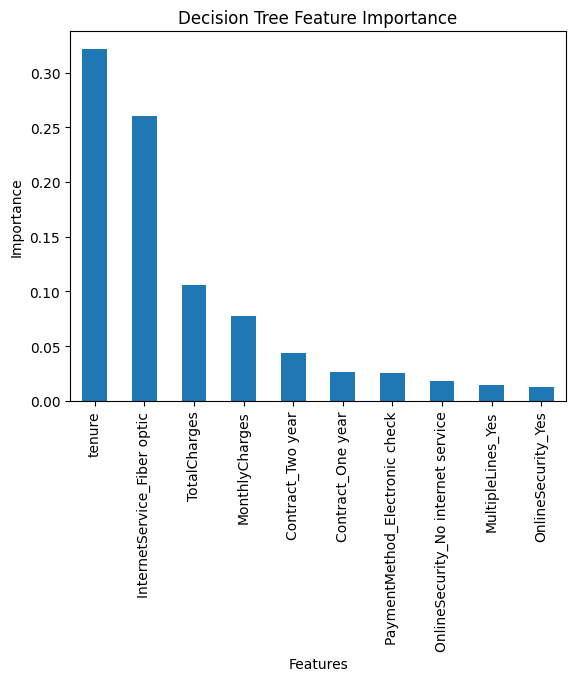

In [30]:
# task 15
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 Important Features:")
print(feature_importance.head(5))

feature_importance.head(10).plot(kind='bar')
plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

Explanation :
The most important features in the Decision Tree are tenure, InternetService_Fiber optic, TotalCharges, MonthlyCharges, and Contract_Two year. Among these, tenure has the highest importance, followed by Fiber optic internet service. These features indicate that customer length of stay, internet service type, charges, and contract type have a strong influence on the model's churn predictions. The important features are generally consistent with the patterns observed in Lab 2 EDA and the Lab 3 Decision Tree, showing that the final model is using meaningful customer and service-related features.

# 10. Kaggle Prediction/Submission

In [32]:
# Task 16

final_predictions = dt_model.predict(X_test)

submission = pd.DataFrame({
    "customerID": X_test.index,
    "Churn": final_predictions
})

submission["Churn"] = submission["Churn"].map({
    0: "No",
    1: "Yes"
})

# Save
submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
display(submission.head())
print("submission.csv saved successfully.")

Submission shape: (1402, 2)


,customerID,Churn
0,743,No
1,668,No
2,5741,No
3,5449,No
4,2020,No


submission.csv saved successfully.


Explanation :
The final model was used to generate churn predictions for the held-out test data. A submission dataframe was created containing the customer identifier and the predicted Churn value (Yes/No). The predictions were then saved in submission.csv, which can be used as a Kaggle-style submission file.

# 11. Conclusion

#Task 17

Explanation :
 The Decision Tree was selected as the final model because it achieved the highest recall and F1-score among the tested models. Its F1-score was 0.5735, which was slightly higher than the Tuned Random Forest F1-score of 0.5688. Compared with the Lab 3 Decision Tree, the final model is essentially the same approach, while Lab 4 provided a broader comparison with Random Forest and hyperparameter tuning. The main limitation is that the recall is still relatively low, meaning the model may miss some customers who are likely to churn. The class imbalance in the dataset also makes churn prediction more challenging.


#Task 18

Explanation : 
If I had more time, I would try other algorithms such as Logistic Regression, Gradient Boosting, or XGBoost and compare their performance. I would also perform deeper hyperparameter tuning using a carefully selected parameter grid. Since the dataset has class imbalance, I would try techniques such as class weights or resampling to improve churn detection. I would also experiment with different prediction thresholds to improve recall. Finally, I would compare all models using cross-validation before selecting the final model.
